In [84]:
import pandas as pd

df = pd.read_csv("archive/product_info.csv")

print("Numri i rreshtave dhe kolonave:")
print(df.shape)

df.head()

Numri i rreshtave dhe kolonave:
(8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [85]:
df.columns.tolist()

['product_id',
 'product_name',
 'brand_id',
 'brand_name',
 'loves_count',
 'rating',
 'reviews',
 'size',
 'variation_type',
 'variation_value',
 'variation_desc',
 'ingredients',
 'price_usd',
 'value_price_usd',
 'sale_price_usd',
 'limited_edition',
 'new',
 'online_only',
 'out_of_stock',
 'sephora_exclusive',
 'highlights',
 'primary_category',
 'secondary_category',
 'tertiary_category',
 'child_count',
 'child_max_price',
 'child_min_price']

In [86]:
df["primary_category"].value_counts()

primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64

In [87]:
df.isnull().sum()

product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
dtype: int64

In [88]:
df_ml = df[[
    "product_name",
    "brand_name",
    "price_usd",
    "primary_category"
]]

df_ml.head()

,product_name,brand_name,price_usd,primary_category
0,Fragrance Discovery Set,19-69,35.0,Fragrance
1,La Habana Eau de Parfum,19-69,195.0,Fragrance
2,Rainbow Bar Eau de Parfum,19-69,195.0,Fragrance
3,Kasbah Eau de Parfum,19-69,195.0,Fragrance
4,Purple Haze Eau de Parfum,19-69,195.0,Fragrance


In [89]:
df_ml["primary_category"].unique()

array(['Fragrance', 'Bath & Body', 'Mini Size', 'Hair', 'Makeup',
       'Skincare', 'Tools & Brushes', 'Men', 'Gifts'], dtype=object)

In [90]:
df_ml = df[[
    "product_name",
    "brand_name",
    "ingredients",
    "price_usd",
    "primary_category"
]]

df_ml["ingredients"].isnull().sum()

np.int64(945)

In [91]:
df_ml["ingredients"] = df_ml["ingredients"].fillna("")

/var/folders/h2/px83ztt151dc59nvkw27n17r0000gn/T/ipykernel_21805/263420922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["ingredients"] = df_ml["ingredients"].fillna("")


In [92]:
df_ml["text"] = (
    df_ml["product_name"] + " " +
    df_ml["brand_name"] + " " +
    df_ml["ingredients"]
)

df_ml[["text", "primary_category"]].head()

/var/folders/h2/px83ztt151dc59nvkw27n17r0000gn/T/ipykernel_21805/3065639024.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["text"] = (


,text,primary_category
0,Fragrance Discovery Set 19-69 ['Capri Eau de P...,Fragrance
1,La Habana Eau de Parfum 19-69 ['Alcohol Denat....,Fragrance
2,Rainbow Bar Eau de Parfum 19-69 ['Alcohol Dena...,Fragrance
3,Kasbah Eau de Parfum 19-69 ['Alcohol Denat. (S...,Fragrance
4,Purple Haze Eau de Parfum 19-69 ['Alcohol Dena...,Fragrance


In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_text = tfidf.fit_transform(df_ml["text"])

print(X_text.shape)

(8494, 5000)


In [94]:
from sklearn.model_selection import train_test_split

y = df_ml["primary_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6795, 5000)
(1699, 5000)


In [95]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [96]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, lr_predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8934667451442024


In [97]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_predictions))

                 precision    recall  f1-score   support

    Bath & Body       0.78      0.42      0.54        67
      Fragrance       0.96      0.97      0.96       277
          Gifts       0.00      0.00      0.00         1
           Hair       0.92      0.95      0.94       301
         Makeup       0.89      0.94      0.92       469
            Men       0.00      0.00      0.00        13
      Mini Size       0.43      0.06      0.10        52
       Skincare       0.86      0.96      0.91       508
Tools & Brushes       0.00      0.00      0.00        11

       accuracy                           0.89      1699
      macro avg       0.54      0.48      0.49      1699
   weighted avg       0.87      0.89      0.87      1699



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


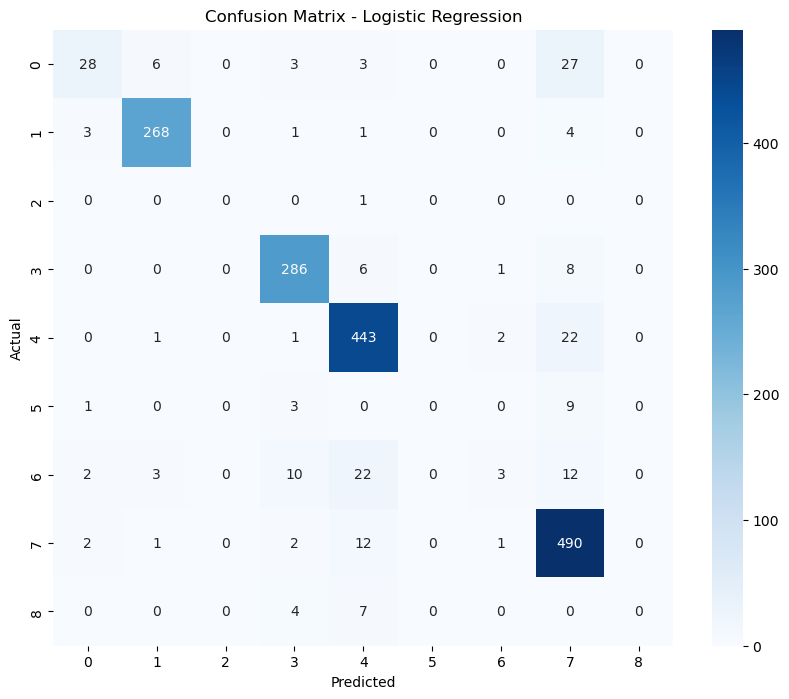

In [98]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [100]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8163625662154208


In [102]:
import pickle

pickle.dump(lr_model, open("glowelle_skin_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("Model saved!")

Model saved!


In [103]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [104]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8663919952913478


In [105]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predictions))

                 precision    recall  f1-score   support

    Bath & Body       0.77      0.36      0.49        67
      Fragrance       0.96      0.97      0.97       277
          Gifts       1.00      1.00      1.00         1
           Hair       0.92      0.90      0.91       301
         Makeup       0.89      0.91      0.90       469
            Men       0.00      0.00      0.00        13
      Mini Size       0.08      0.04      0.05        52
       Skincare       0.81      0.94      0.87       508
Tools & Brushes       0.50      0.18      0.27        11

       accuracy                           0.87      1699
      macro avg       0.66      0.59      0.61      1699
   weighted avg       0.85      0.87      0.85      1699



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


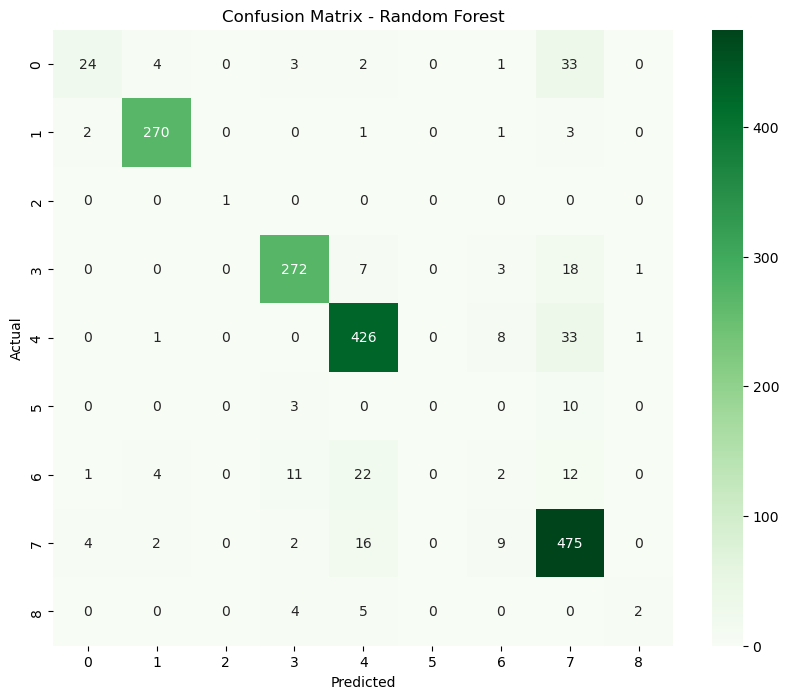

In [106]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(10,8))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [107]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

In [108]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.8675691583284285


In [109]:
from sklearn.metrics import classification_report

print(classification_report(y_test, nb_predictions))

                 precision    recall  f1-score   support

    Bath & Body       0.82      0.13      0.23        67
      Fragrance       0.94      0.97      0.96       277
          Gifts       0.00      0.00      0.00         1
           Hair       0.91      0.93      0.92       301
         Makeup       0.88      0.92      0.90       469
            Men       0.00      0.00      0.00        13
      Mini Size       0.00      0.00      0.00        52
       Skincare       0.80      0.96      0.87       508
Tools & Brushes       0.00      0.00      0.00        11

       accuracy                           0.87      1699
      macro avg       0.48      0.43      0.43      1699
   weighted avg       0.83      0.87      0.84      1699



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [110]:
from sklearn.neural_network import MLPClassifier

mlp1 = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

mlp1.fit(X_train, y_train)

mlp1_predictions = mlp1.predict(X_test)

In [111]:
from sklearn.metrics import accuracy_score

mlp1_accuracy = accuracy_score(
    y_test,
    mlp1_predictions
)

print("MLP 1 Accuracy:", mlp1_accuracy)

MLP 1 Accuracy: 0.8969982342554443


In [112]:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(200,100),
    max_iter=300,
    random_state=42
)

mlp2.fit(X_train, y_train)

mlp2_predictions = mlp2.predict(X_test)

In [113]:
mlp2_accuracy = accuracy_score(
    y_test,
    mlp2_predictions
)

print("MLP 2 Accuracy:", mlp2_accuracy)

MLP 2 Accuracy: 0.8934667451442024


In [114]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes",
        "MLP 1",
        "MLP 2"
    ],
    "Accuracy": [
        0.8934667451442024,
        0.8163625662154208,
        0.8663919952913478,
        0.8675691583284285,
        0.8969982342554443,
        0.8934667451442024
    ]
})

results = results.sort_values("Accuracy", ascending=False)

results

,Model,Accuracy
4,MLP 1,0.896998
0,Logistic Regression,0.893467
5,MLP 2,0.893467
3,Naive Bayes,0.867569
2,Random Forest,0.866392
1,Decision Tree,0.816363


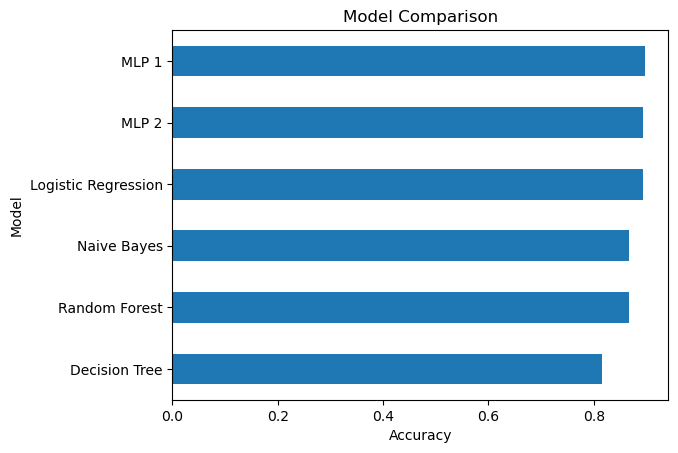

In [115]:
import matplotlib.pyplot as plt

results.sort_values("Accuracy").plot(
    x="Model",
    y="Accuracy",
    kind="barh",
    legend=False
)

plt.title("Model Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

In [116]:
import pickle

model = pickle.load(open("glowelle_skin_model.pkl", "rb"))
tfidf = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

sample = "Vitamin C serum for brightening skin with hyaluronic acid"

sample_vector = tfidf.transform([sample])

prediction = model.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: Skincare


In [117]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_text)

df_ml["cluster"] = clusters

df_ml[["product_name", "primary_category", "cluster"]].head(10)

/var/folders/h2/px83ztt151dc59nvkw27n17r0000gn/T/ipykernel_21805/1539778704.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml["cluster"] = clusters


,product_name,primary_category,cluster
0,Fragrance Discovery Set,Fragrance,3
1,La Habana Eau de Parfum,Fragrance,3
2,Rainbow Bar Eau de Parfum,Fragrance,3
3,Kasbah Eau de Parfum,Fragrance,3
4,Purple Haze Eau de Parfum,Fragrance,3
5,Kasbah Eau de Parfum Travel Spray,Fragrance,3
6,Purple Haze Eau de Parfum Travel Spray,Fragrance,3
7,Invisible Post Eau de Parfum,Fragrance,3
8,Capri Eau de Parfum,Fragrance,3
9,Invisible Post Eau de Parfum Travel Spray,Fragrance,3


In [118]:
df_ml["cluster"].value_counts()

cluster
2    3786
1    2186
0    1514
3    1008
Name: count, dtype: int64

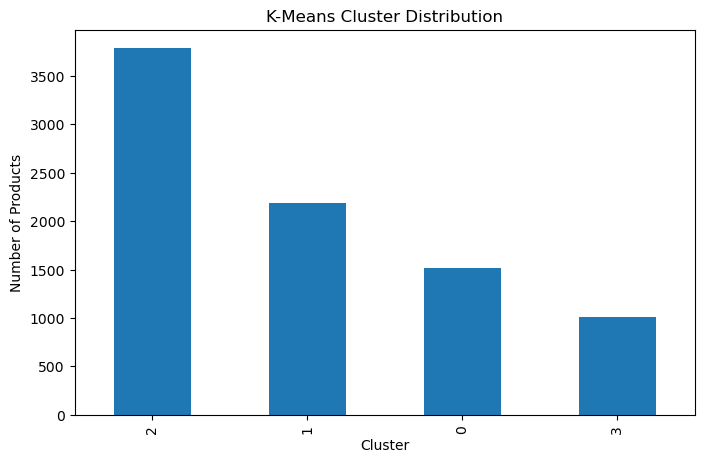

In [119]:
import matplotlib.pyplot as plt

cluster_counts = df_ml["cluster"].value_counts()

plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar")

plt.title("K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")

plt.show()

In [120]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=2000)

X_selected = selector.fit_transform(X_text, y)

print(X_text.shape)
print(X_selected.shape)

(8494, 5000)
(8494, 2000)


In [121]:
from sklearn.model_selection import train_test_split

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_fs = LogisticRegression(max_iter=1000)

lr_fs.fit(X_train_fs, y_train_fs)

pred_fs = lr_fs.predict(X_test_fs)

print("Accuracy with Feature Selection:",
      accuracy_score(y_test_fs, pred_fs))

Accuracy with Feature Selection: 0.8881695114773396


In [122]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10}
Best Score: 0.9011037527593819


In [123]:
pd.crosstab(
    df_ml["primary_category"],
    df_ml["cluster"]
)

cluster,0,1,2,3
primary_category,,,,
Bath & Body,13,85,290,17
Fragrance,3,446,29,954
Gifts,0,4,0,0
Hair,5,428,1014,17
Makeup,1379,667,321,2
Men,1,7,50,2
Mini Size,77,80,120,11
Skincare,36,417,1962,5
Tools & Brushes,0,52,0,0


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

# Decision Tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10]
    },
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Decision Tree best params:", dt_grid.best_params_)
print("Decision Tree best score:", dt_grid.best_score_)


# Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {
        "n_estimators": [50, 100, 200],
        "max_depth": [10, 20, None]
    },
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Random Forest best params:", rf_grid.best_params_)
print("Random Forest best score:", rf_grid.best_score_)


# Naive Bayes
nb_grid = GridSearchCV(
    MultinomialNB(),
    {
        "alpha": [0.1, 0.5, 1.0]
    },
    cv=3,
    scoring="accuracy"
)

nb_grid.fit(X_train, y_train)

print("Naive Bayes best params:", nb_grid.best_params_)
print("Naive Bayes best score:", nb_grid.best_score_)


# Neural Network
mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=42),
    {
        "hidden_layer_sizes": [(100,), (200,100)],
        "activation": ["relu", "tanh"],
        "alpha": [0.0001, 0.001]
    },
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

mlp_grid.fit(X_train, y_train)

print("MLP best params:", mlp_grid.best_params_)
print("MLP best score:", mlp_grid.best_score_)

Decision Tree best params: {'max_depth': None, 'min_samples_split': 10}
Decision Tree best score: 0.8116261957321559
Random Forest best params: {'max_depth': None, 'n_estimators': 100}
Random Forest best score: 0.8507726269315673
Naive Bayes best params: {'alpha': 0.1}
Naive Bayes best score: 0.8765268579838117


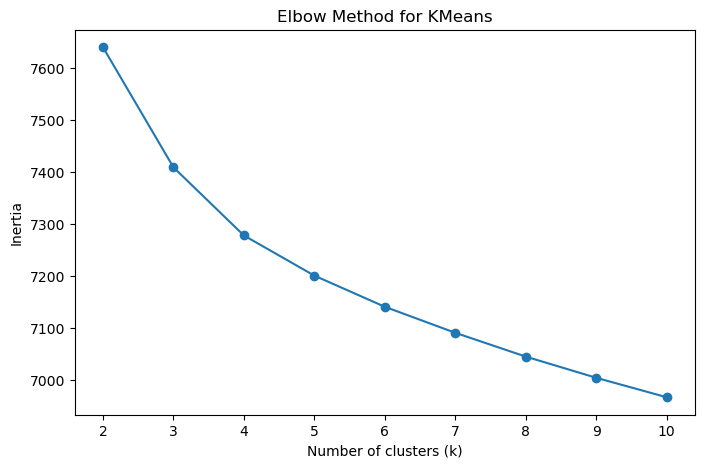

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_text)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

In [ ]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=42)

X_2d = svd.fit_transform(X_text)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_text)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=10)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("KMeans Clustering Visualization with SVD")
plt.show()